<a href="https://colab.research.google.com/github/GabAsencios/FocusGuard/blob/main/FocusGuard_ScreenClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FocusGuard - A Multimodal Distraction Detection System for Productivity Monitoring**

## **Abstract**
   Abstract here. Give an executive summary of your project: goal, methods, results, conclusions. Usually no more than 200 words.


## **Introduction**

Staying focused during work or study sessions has become increasingly difficult, with distractions such as video games, YouTube, and Twitch accessible at any moment. Many individuals lose significant productive time without realizing it, and existing tools like RescueTime track application usage via OS APIs rather than visual content, making them unable to capture physical behavioral cues such as phone usage or leaving the workstation. Website blockers require manual setup and are easily bypassed, while time tracking apps rely on self-reporting which is inherently inaccurate.

Prior work on webcam-based engagement detection, such as DAiSEE (Gupta et al., 2016), focuses on facial expression classification rather than objective behavioral events. Real-time object detection builds on YOLOv8 (Jocher et al., 2023), pretrained on COCO (Lin et al., 2014), which provides robust person and cell phone detection applicable to absence and phone-usage monitoring. Screen content classification has been explored in the context of task recognition from screenshots, though no public labeled dataset targeting specific distraction applications exists.

This project proposes FocusGuard, a dual-component distraction detection system that passively monitors users by combining screen content classification with webcam-based behavioral detection. The screen component fine-tunes a pretrained ResNet18 (He et al., 2016) on a self-collected dataset of 4,076 labeled screenshots across four classes: Gaming, YouTube, Twitch, and Productive. The webcam component uses pretrained YOLOv8 with a custom temporal reasoning layer to filter accidental detections before confirming and logging events. The screen classifier achieved 100% test accuracy using a two-phase training strategy with AdamW optimization, comfortably exceeding the 85% target. The main challenge is dataset diversity, as the self-collected nature of the data introduces visual similarity between consecutive frames that may inflate benchmark scores relative to fully independent evaluations.

## **Methodology**
Describe the important steps you took to achieve your goal. Focus more on the most important steps (preprocessing, extra features, model aspects) that turned out to be important. Mention the original aspects of the project and state how they relate to existing work.

In this section, you can add **text** and **figures**. For instance, it is strongly suggested to add a picture of the best machine learning model that you implemented to solve your problem (and describe it).


## **Experimental Setup**
Describe the datasets used for your experiments. List the machine learning techniques used to solve your problem and report the corresponding hyperparameters.

In this section, you can add **text**, **tables**, and **figures**.

## **Experimental Results**
Describe here the main experimental results. Critically discuss them. Compare them with results available in the literature (if applicable).

In this section, you can add **text** and **figures**, **tables**, **plots**, and code. Make sure the code is runnable and replicable.

## **Conclusions**

Summarize what you could and could not conclude based on your experiments.
In this section, you can add **text**.



## **References**
- He, K., et al. (2016). Deep residual learning for image recognition. CVPR.
- Jocher, G., et al. (2023). Ultralytics YOLOv8. https://github.com/ultralytics/ultralytics
- Gupta, A., et al. (2016). DAiSEE: Towards user engagement recognition in the wild. arXiv:1609.01885
- Lin, T.Y., et al. (2014). Microsoft COCO: Common objects in context. ECCV.

## **Screen Detection Component: Resnet18 + Custom Dataset (4000+ screenshots)**





In this notebook i will train RESNET18 for screenshoot classification using my custom datasets.



In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU found')

2.6.0+cu124
True
NVIDIA GeForce RTX 2070


In [ ]:
import torch.multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
import shutil
import os
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.model_selection import train_test_split

In [ ]:
# Force device to CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('Warning: CUDA not available, falling back to CPU.')
else:
    print(f'Using device: {device}')

Using device: cuda


In [ ]:
# ==========================================
# GLOBAL HYPERPARAMETERS & CONFIG
# ==========================================

# Dataset Config
NUM_CLASSES = 4
data_dir = r'C:\Users\angel\PycharmProjects\FocusGuard\data'

# Training Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9
NUM_EPOCHS = 8
DROPOUT_RATE = 0.5

# Hardware Config
NUM_WORKERS = 4
PIN_MEMORY = True

print("Global hyperparameters initialized.")

Global hyperparameters initialized.


In [ ]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Training transform with augmentation to improve generalization due to my limited Dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Val/test transform - no augmentation, only resize and normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from collections import Counter

if os.path.exists(data_dir):
    # Load full dataset with val/test transform as default
    full_dataset = ImageFolder(data_dir, transform=val_test_transform)
    labels = [label for _, label in full_dataset.samples]

    # Count images per class
    class_counts = Counter(labels)
    class_names = full_dataset.classes

    # Stratified split to preserve class balance across all three sets
    indices = list(range(len(full_dataset)))
    train_idx, temp_idx, _, temp_labels = train_test_split(
        indices, labels, test_size=0.2, stratify=labels, random_state=42
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
    )

    # Apply augmentation only to train subset
    train_dataset = Subset(ImageFolder(data_dir, transform=train_transform), train_idx)
    val_dataset   = Subset(full_dataset, val_idx)
    test_dataset  = Subset(full_dataset, test_idx)

    print(f'Local dataset loaded from: {data_dir}')
    print(f'Total images : {len(full_dataset)}')
    print('-' * 30)
    print('Class Distribution:')
    for idx, name in enumerate(class_names):
        print(f'  {name:<12}: {class_counts[idx]} images')
    print('-' * 30)
    print(f'Train set    : {len(train_dataset)} images')
    print(f'Val set      : {len(val_dataset)} images')
    print(f'Test set     : {len(test_dataset)} images')

    # Display first 5 samples to confirm mapping
    print('\nSample Label Mapping (first 5 samples):')
    for i in range(5):
        path, label = full_dataset.samples[i]
        print(f'  {os.path.basename(path)} -> {class_names[label]}')
else:
    print(f'Error: Local dataset path not found at {data_dir}. Please ensure the data folder exists.')

Local dataset loaded from: C:\Users\angel\PycharmProjects\FocusGuard\data
Total images : 4076
------------------------------
Class Distribution:
  Gaming      : 1022 images
  Productive  : 1042 images
  Twitch      : 1000 images
  YouTube     : 1012 images
------------------------------
Train set    : 3260 images
Val set      : 408 images
Test set     : 408 images

Sample Label Mapping (first 5 samples):
  Gaming_20260416_211926_00000.png -> Gaming
  Gaming_20260416_211930_00001.png -> Gaming
  Gaming_20260416_211933_00002.png -> Gaming
  Gaming_20260416_211936_00003.png -> Gaming
  Gaming_20260416_211939_00004.png -> Gaming


In [ ]:
# Create DataLoaders using global config
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'DataLoaders ready | Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

DataLoaders ready | Batch size: 64
Train batches: 51 | Val batches: 7 | Test batches: 7


# The Two-Phase Strategy

This is why highly effective training loops use a two-step approach:

**Phase 1 (Frozen)**: You freeze the entire convolutional base and only train the new classification layer. This allows the new layer to safely align itself with the existing features.

**Phase 2 (Unfrozen/Fine-Tuning)**: You unfreeze the top layers (like layer4) and drop the learning rate significantly. This gently nudges the model to look for highly specific visual cues for your specific task, like recognizing a Twitch interface, without wrecking the foundational edge detectors in the earlier layers.

### Update your dataset paths below

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Get dataset sizes from loaders to avoid relying on globals
    num_train = len(train_loader.dataset)
    num_val = len(val_loader.dataset)

    for epoch in range(num_epochs):

        # Unfreeze layer4 at epoch 5
        if epoch == 5:
            print("Unfreezing layer4...")
            for param in model.layer4.parameters():
                param.requires_grad = True

            # Recreate AdamW optimizer with new trainable params
            # We reduce the base learning rate by 10 for fine-tuning
            current_lr = optimizer.param_groups[0]['lr']
            current_wd = optimizer.param_groups[0]['weight_decay']

            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=current_lr / 10,
                weight_decay=current_wd
            )

        print(f'\n{"="*60}')
        print(f'EPOCH [{epoch+1}/{num_epochs}]')
        print(f'{"="*60}')

        model.train()

        running_loss = 0.0
        running_corrects = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if (i + 1) % 10 == 0:
                batch_acc = running_corrects.float() / ((i + 1) * train_loader.batch_size)
                print(f'  Epoch [{epoch+1}/{num_epochs}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f} | Acc: {batch_acc:.4f}')

        train_loss = running_loss / num_train
        train_acc = running_corrects.float() / num_train

        model.eval()

        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        val_loss = running_loss / num_val
        val_acc = running_corrects.float() / num_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())

        print(f'\n--- Epoch [{epoch+1}/{num_epochs}] Summary ---')
        print(f'  Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}')
        print(f'  Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.4f}')
        print(f'  Overfit Gap (val - train loss): {val_loss - train_loss:.4f}')

    return history

# Comparing optimizers and hyperparameters

Defining loss function and optimizer (try different optimizers)

Function to train model(update)

fine-tune to custom dataset (training takes about 30min)

Training on: cuda
Model device: cuda:0

EPOCH [1/8]
  Epoch [1/8] | Batch [10/51] | Loss: 1.4026 | Acc: 0.3125
  Epoch [1/8] | Batch [20/51] | Loss: 1.1847 | Acc: 0.3875
  Epoch [1/8] | Batch [30/51] | Loss: 0.9094 | Acc: 0.4500
  Epoch [1/8] | Batch [40/51] | Loss: 0.7708 | Acc: 0.5012
  Epoch [1/8] | Batch [50/51] | Loss: 0.7609 | Acc: 0.5394

--- Epoch [1/8] Summary ---
  Train Loss : 1.0804 | Train Acc : 0.5420
  Val Loss   : 0.6699 | Val Acc   : 0.7672
  Overfit Gap (val - train loss): -0.4104

EPOCH [2/8]
  Epoch [2/8] | Batch [10/51] | Loss: 0.7205 | Acc: 0.6781
  Epoch [2/8] | Batch [20/51] | Loss: 0.6006 | Acc: 0.7023
  Epoch [2/8] | Batch [30/51] | Loss: 0.6826 | Acc: 0.7229
  Epoch [2/8] | Batch [40/51] | Loss: 0.6167 | Acc: 0.7398
  Epoch [2/8] | Batch [50/51] | Loss: 0.5138 | Acc: 0.7462

--- Epoch [2/8] Summary ---
  Train Loss : 0.6646 | Train Acc : 0.7457
  Val Loss   : 0.4465 | Val Acc   : 0.8725
  Overfit Gap (val - train loss): -0.2181

EPOCH [3/8]
  Epoch [3/8] | Ba

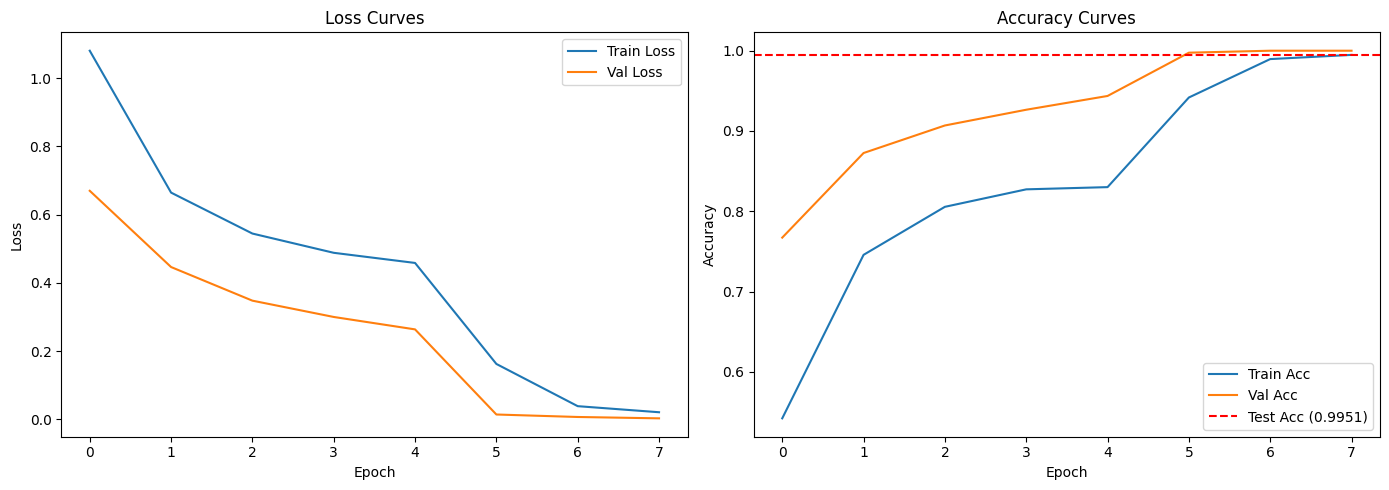

In [ ]:
# Load the pre-trained ResNet-18 model
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Then replace with dropout + linear
in_features = model.fc.in_features
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(p=DROPOUT_RATE),
    torch.nn.Linear(in_features, NUM_CLASSES)
)

# Ensure fc is trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device and start training
model = model.to(device)

# Define loss and optimizer using global config
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.fc.parameters(),   # ONLY fc trains initially
    lr=LEARNING_RATE,
    # momentum=MOMENTUM,     # ONLY for SDG
    weight_decay=WEIGHT_DECAY
)

# Confirm device before training
print(f'Training on: {device}')
print(f'Model device: {next(model.parameters()).device}')

# Start training
history = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)

# Evaluate final model performance on the test set
# Test evaluation is done only once after training to avoid data leakage
model.eval()
test_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
test_acc = test_corrects.float() / len(test_dataset)

# Print final summary metrics across all three splits
print("\n" + "="*30)
print(f"Final Training Accuracy:   {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Final Test Accuracy:       {test_acc:.4f}")
print("="*30 + "\n")

# Plot loss and accuracy curves to visualize training behavior
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves - a large gap between train and val indicates overfitting
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy curves - add a horizontal line for final test accuracy as reference
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.axhline(y=test_acc.item(), color='r', linestyle='--', label=f'Test Acc ({test_acc:.4f})')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

Testing unfreezing

### Evaluation Results

The combined evaluation above provides class-level performance metrics and visualizes where the model might be confusing specific categories.

Overall Accuracy: 0.9951

Detailed Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

      Gaming       0.99      0.99      0.99       102
  Productive       1.00      1.00      1.00       105
      Twitch       0.99      0.99      0.99       100
     YouTube       1.00      1.00      1.00       101

    accuracy                           1.00       408
   macro avg       1.00      1.00      1.00       408
weighted avg       1.00      1.00      1.00       408



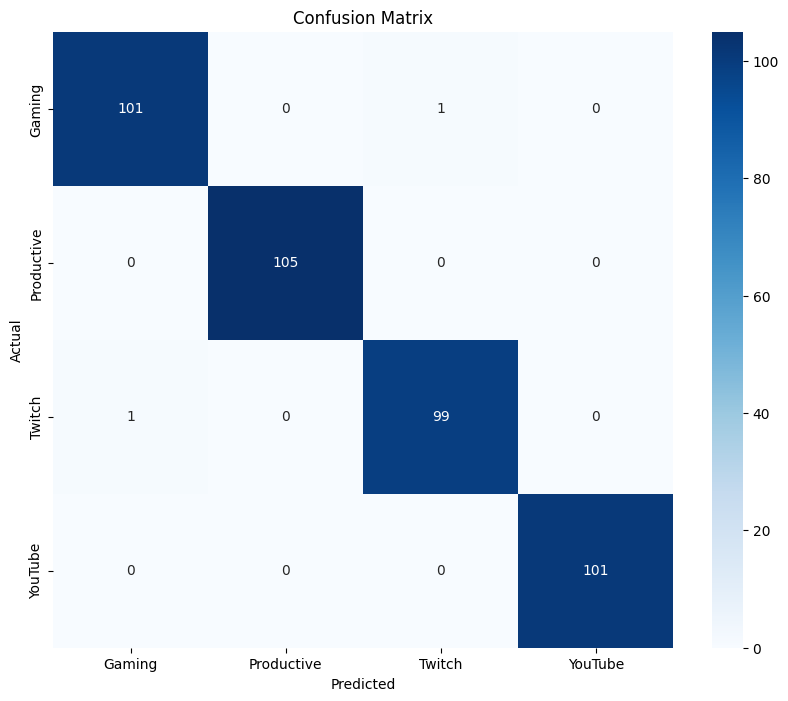

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def comprehensive_evaluation(model, test_loader, device):
    """
    Performs a single inference pass and generates all metrics and visualizations.
    """
    model.eval()
    all_labels = []
    all_preds = []
    classes = test_loader.dataset.dataset.classes

    # 1. Single Inference Pass
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # 2. Compute and Print Metrics in text format
    overall_accuracy = accuracy_score(all_labels, all_preds)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print("\nDetailed Classification Report:")
    print("-" * 53)
    # This generates the text format table for precision, recall, f1, and support
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run the consolidated evaluation
comprehensive_evaluation(model, test_loader, device)

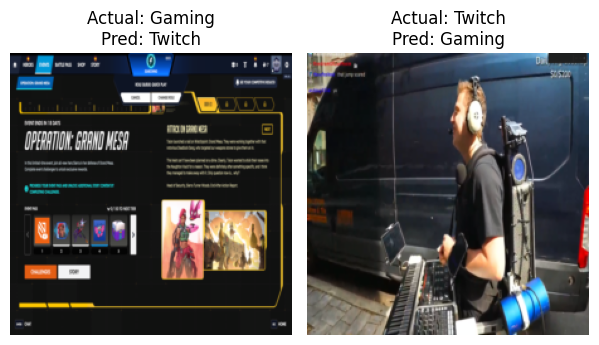

In [ ]:
def visualize_misclassified(model, test_loader, device, num_images=5):
    model.eval()
    misclassified_images = []
    actual_labels = []
    pred_labels = []
    classes = test_loader.dataset.dataset.classes

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    actual_labels.append(classes[labels[i]])
                    pred_labels.append(classes[preds[i]])
                if len(misclassified_images) >= num_images:
                    break
            if len(misclassified_images) >= num_images:
                break

    plt.figure(figsize=(15, 5))
    for i in range(len(misclassified_images)):
        plt.subplot(1, num_images, i + 1)
        img = misclassified_images[i].numpy().transpose((1, 2, 0))
        # Unnormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f'Actual: {actual_labels[i]}\nPred: {pred_labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_misclassified(model, test_loader, device)

### Download Model for Local Inference

In [ ]:
# import torch

# # 1. Save the model state dictionary
# model_filename = 'resnet18_screen_AdamW_model.pth'
# torch.save(model.state_dict(), model_filename)

# print(f'Model successfully saved locally as: {model_filename}')
# print(f'Location: {os.path.abspath(model_filename)}')

Model successfully saved locally as: resnet18_screen_AdamW_model.pth
Location: C:\Users\angel\resnet18_screen_AdamW_model.pth
